
# Прогноз загруженности метро — AutoML (H2O), SARIMA и автоматическое извлечение признаков (tsfresh)

Этот ноутбук:
- **берет датасет** с UCI,
- смотрит **EDA**, проводит обработку дубликатов и **выравнивание временного индекса** с **линейной интерполяцией**,
- строит **baseline** по средним значениям `weekday × hour`,
- генерирует **календарные признаки** + **такие как лаги и скользящие средние**,
- добавляет **автоматические признаки** с помощью `tsfresh`,
- обучает **SARIMAX** (с недельной сезонностью 168 = 24×7, с `temp` как экзогенным признаком),
- запускает **H2O AutoML** как альтернативную модель,
- сравнивает метрики (MAE / RMSE / MAPE) на **отложенных 2 неделях**,


In [1]:
# Установка condacolab и инсталляция Conda
!pip install -q condacolab
import condacolab
condacolab.install()

✨🍰✨ Everything looks OK!


In [2]:
# ======================
# Установка зависимостей
# ======================
%pip -q install --upgrade pip
# Install Java and H2O using conda
!conda install -c conda-forge h2o-py openjdk -y -q
%pip -q install -U h2o tsfresh pmdarima statsmodels holidays matplotlib pandas


Channels:
 - conda-forge
Platform: linux-64
Solving environment: ...working... done

# All requested packages already installed.



In [3]:
# Проверка версий после перезапуска
import numpy as _np, pandas as _pd, statsmodels as _sm
import tsfresh as _tsf, h2o as _h2o
print("numpy:", _np.__version__)
print("pandas:", _pd.__version__)
print("statsmodels:", _sm.__version__)
print("tsfresh:", _tsf.__version__)
print("h2o:", _h2o.__version__)


numpy: 1.26.4
pandas: 2.3.3
statsmodels: 0.14.5
tsfresh: 0.21.1
h2o: 3.46.0.8


In [4]:
# =============
# Импорт модулей
# =============
import io
import os
import math
import json
import time
import zipfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import timedelta
from dateutil.relativedelta import relativedelta

from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm

from tsfresh.feature_extraction import extract_features, EfficientFCParameters
from tsfresh.utilities.dataframe_functions import make_forecasting_frame

import h2o
from h2o.automl import H2OAutoML


## 1) Загрузка данных автоматически

In [5]:
# ======================
# Автоматическая загрузка данных Metro Interstate Traffic Volume
# ======================

import pandas as pd

try:
    # 1) Предпочтительный вариант: ucimlrepo (официально от UCI)
    %pip -q install -U ucimlrepo
    from ucimlrepo import fetch_ucirepo

    ds = fetch_ucirepo(id=492)  # Metro Interstate Traffic Volume
    df = pd.concat([ds.data.features, ds.data.targets], axis=1)
    print("Данные загружены через ucimlrepo (UCI id=492).")

except Exception as e:
    print("ucimlrepo не сработал, пробуем загрузить zip напрямую с UCI...")
    import io, requests, zipfile, gzip

    zip_url = "https://archive.ics.uci.edu/static/public/492/metro%2Binterstate%2Btraffic%2Bvolume.zip"
    r = requests.get(zip_url, timeout=60)
    r.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(r.content)) as zf:
        # Ищем CSV или CSV.GZ внутри архива
        names = zf.namelist()
        fname = next(n for n in names if n.lower().endswith((".csv", ".csv.gz")))
        data_bytes = zf.read(fname)

        if fname.lower().endswith(".gz"):
            df = pd.read_csv(io.BytesIO(gzip.decompress(data_bytes)))
        else:
            df = pd.read_csv(io.BytesIO(data_bytes))

    print("Данные загружены напрямую из UCI zip.")

print("Форма:", df.shape)
df.head()


Данные загружены через ucimlrepo (UCI id=492).
Форма: (48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


## 2) Базовый EDA

Диапазон дат: 2012-10-02 09:00:00 → 2018-09-30 23:00:00
Количество строк: 48204

Пропуски по столбцам:
date_time             0
holiday           48143
temp                  0
traffic_volume        0
dtype: int64

Уникальные значения holiday: 11
holiday
NaN                          48143
Labor Day                        7
Thanksgiving Day                 6
Christmas Day                    6
New Years Day                    6
Martin Luther King Jr Day        6
Columbus Day                     5
Veterans Day                     5
Washingtons Birthday             5
Memorial Day                     5
Name: count, dtype: int64


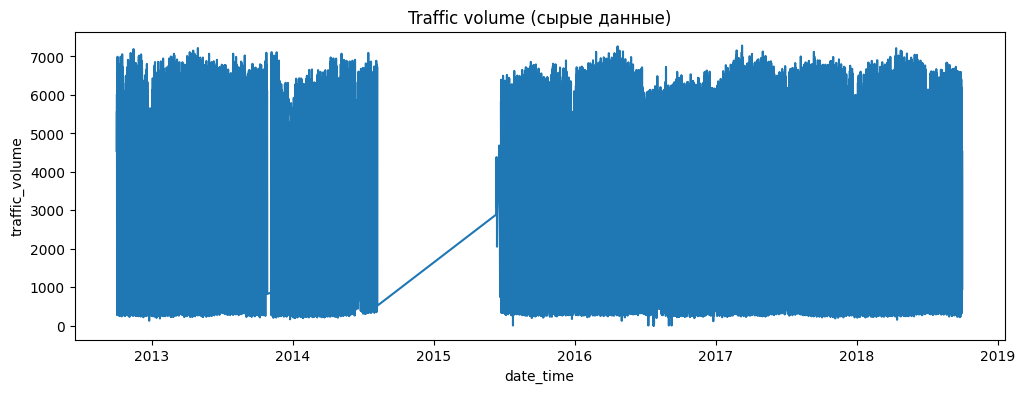

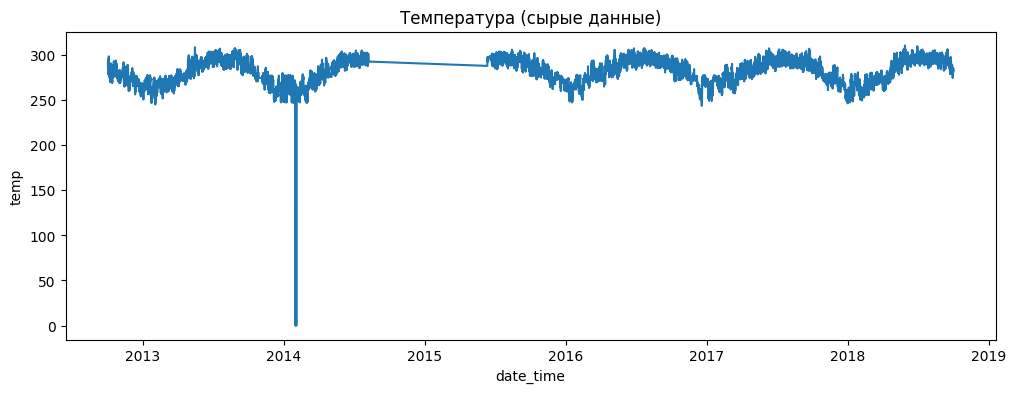

In [6]:

use_cols = ["date_time", "holiday", "temp", "traffic_volume"]
df = df[use_cols].copy()

# Приводим типы
df["date_time"] = pd.to_datetime(df["date_time"])
df = df.sort_values("date_time").reset_index(drop=True)

print("Диапазон дат:", df["date_time"].min(), "→", df["date_time"].max())
print("Количество строк:", len(df))

print("\nПропуски по столбцам:")
print(df.isna().sum())

print("\nУникальные значения holiday:", df["holiday"].nunique())
print(df["holiday"].value_counts(dropna=False).head(10))

# Визуализации
plt.figure(figsize=(12,4))
plt.plot(df["date_time"], df["traffic_volume"])
plt.title("Traffic volume (сырые данные)")
plt.xlabel("date_time"); plt.ylabel("traffic_volume")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(df["date_time"], df["temp"])
plt.title("Температура (сырые данные)")
plt.xlabel("date_time"); plt.ylabel("temp")
plt.show()


## 3) Очистка: удаление дубликатов и выравнивание временного индекса + интерполяция

Дубликатов по date_time: 7629
Уникальные интервалы: <TimedeltaArray>
['0 days 01:00:00']
Length: 1, dtype: timedelta64[ns]
Есть ли пропуски после выравнивания: {'holiday': 0, 'temp': 0, 'traffic_volume': 0}


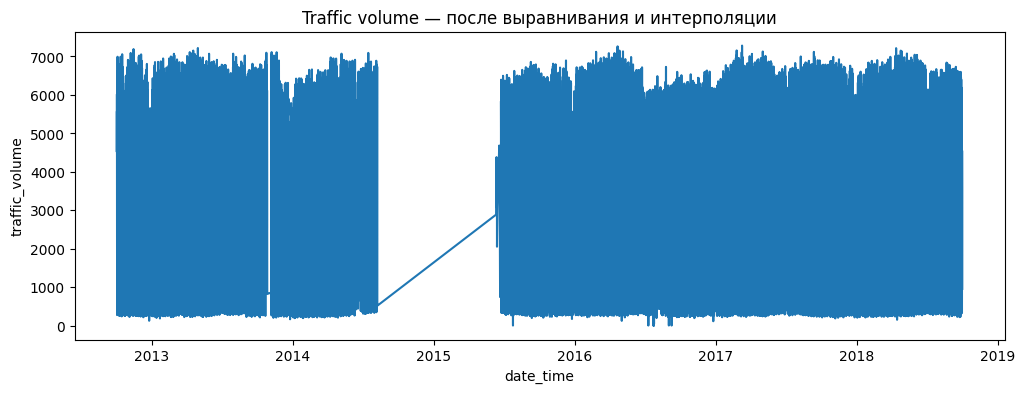

In [7]:

# Смотрим на дубликаты по штампу времени
dup_count = df["date_time"].duplicated().sum()
print("Дубликатов по date_time:", dup_count)

# Удаляем дубликаты, оставляя последнюю запись
df = df.drop_duplicates(subset=["date_time"], keep="last").sort_values("date_time").reset_index(drop=True)

# Делаем индекс периодическим с шагом 1 час
full_index = pd.date_range(df["date_time"].min(), df["date_time"].max(), freq="H")
df = df.set_index("date_time").reindex(full_index)
df.index.name = "date_time"

# Интерполяция числовых признаков, заполнение holiday вперёд-назад и "None"
num_cols = ["temp", "traffic_volume"]
df[num_cols] = df[num_cols].interpolate(method="linear")

# holiday приведём к строке и заполним NaN как 'None', затем вперёд-назад
df["holiday"] = df["holiday"].astype("string")
df["holiday"] = df["holiday"].fillna("None")
df["holiday"] = df["holiday"].ffill().bfill()

# Проверка равномерности
delta = df.index.to_series().diff().dropna()
print("Уникальные интервалы:", delta.unique()[:5])
print("Есть ли пропуски после выравнивания:", df.isna().sum().to_dict())

# Визуально проверим после очистки
plt.figure(figsize=(12,4))
plt.plot(df.index, df["traffic_volume"])
plt.title("Traffic volume — после выравнивания и интерполяции")
plt.xlabel("date_time"); plt.ylabel("traffic_volume")
plt.show()


## 4) Генерация признаков

In [8]:
# ======================
# генерация признаков
# ======================
import numpy as np, pandas as pd, gc

data = df.copy()

# ---- downcast базовых столбцов ----
for col in ["traffic_volume", "temp"]:
    data[col] = pd.to_numeric(data[col], errors="coerce", downcast="float").astype("float32")

# индексы и базовые календарные фичи (инт и float32)
data = data.sort_index()
data["hour"] = data.index.hour.astype("int8")
data["weekday"] = data.index.weekday.astype("int8")
data["is_weekend"] = (data["weekday"] >= 5).astype("int8")

# holiday → bool/инт (экономнее, чем строка)
if "holiday" in data.columns:
    data["holiday"] = data["holiday"].astype("string")
    data["is_holiday"] = (data["holiday"] != "None").astype("int8")
else:
    data["is_holiday"] = 0

# циклические фичи (float32)
data["hour_sin"] = np.sin(2*np.pi*data["hour"]/24).astype("float32")
data["hour_cos"] = np.cos(2*np.pi*data["hour"]/24).astype("float32")
data["wday_sin"] = np.sin(2*np.pi*data["weekday"]/7).astype("float32")
data["wday_cos"] = np.cos(2*np.pi*data["weekday"]/7).astype("float32")

# ---- компактные лаги и скользящие средние ----
# (минимальный набор, достаточный для бустингов/автоML)
lag_list = [1, 24, 168]          # 1ч, 1д, 1нед
win_list = [3, 24, 168]          # короткая/дневная/недельная

for lag in lag_list:
    data[f"y_lag_{lag}"] = data["traffic_volume"].shift(lag).astype("float32")

for win in win_list:
    data[f"y_rollmean_{win}"]   = data["traffic_volume"].shift(1).rolling(win, min_periods=1).mean().astype("float32")
    data[f"temp_rollmean_{win}"] = data["temp"].shift(1).rolling(win, min_periods=1).mean().astype("float32")

# ======================
# Лёгкий режим tsfresh
# ======================
USE_TSFRESH = True

if USE_TSFRESH:
    from tsfresh.feature_extraction import extract_features, MinimalFCParameters
    from tsfresh.utilities.dataframe_functions import make_forecasting_frame

    # Считаем фичи ТОЛЬКО на хвосте ряда, чтобы не взорвать RAM
    last_n = 15000
    series = data["traffic_volume"].iloc[-last_n:].copy()

    # Небольшой max_timeshift (иначе сильно растёт X_ts)
    X_ts, y_ts = make_forecasting_frame(series, kind="traffic",
                                        max_timeshift=8,
                                        rolling_direction=1)

    fc_params = MinimalFCParameters()  # меньше фич
    tsfresh_feats = extract_features(
        X_ts,
        column_id="id",
        column_sort="time",
        column_value="value",
        default_fc_parameters=fc_params,
        disable_progressbar=True,
        n_jobs=1,          # не распараллеливаем (экономим RAM)
        chunksize=2000     # небольшие чанки
    )

    # Приведём типы и подчистим RAM
    for c in tsfresh_feats.columns:
        tsfresh_feats[c] = pd.to_numeric(tsfresh_feats[c], errors="coerce", downcast="float").astype("float32")

    # выравнивание по времени: результаты соответствуют хвосту ряда
    tsfresh_feats.index.name = "id"
    aligned_index = data.index[-len(tsfresh_feats):]
    aligned = tsfresh_feats.set_index(aligned_index)
    aligned.columns = [f"tsf_{c}" for c in aligned.columns]

    # join только по хвосту (не копируем всю таблицу)
    data.iloc[-len(aligned):] = data.iloc[-len(aligned):].join(aligned)

    # Чистим временные объекты
    del X_ts, y_ts, tsfresh_feats, aligned
    gc.collect()

# ---- финальная чистка ----
data = data.dropna().copy()

# Ещё раз даункастим всё возможное до float32/int16
for c in data.columns:
    if pd.api.types.is_float_dtype(data[c]):
        data[c] = data[c].astype("float32")
    elif pd.api.types.is_integer_dtype(data[c]):
        # подобрать компактный int
        if data[c].max() <= np.iinfo(np.int8).max and data[c].min() >= np.iinfo(np.int8).min:
            data[c] = data[c].astype("int8")
        elif data[c].max() <= np.iinfo(np.int16).max and data[c].min() >= np.iinfo(np.int16).min:
            data[c] = data[c].astype("int16")

print("Финальная форма данных с признаками:", data.shape)
print(data.info(memory_usage="deep"))
data.head()


Rolling: 100%|██████████| 15000/15000 [01:19<00:00, 188.77it/s]


Финальная форма данных с признаками: (52383, 20)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52383 entries, 2012-10-09 09:00:00 to 2018-09-30 23:00:00
Freq: h
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   holiday            52383 non-null  string 
 1   temp               52383 non-null  float32
 2   traffic_volume     52383 non-null  float32
 3   hour               52383 non-null  int8   
 4   weekday            52383 non-null  int8   
 5   is_weekend         52383 non-null  int8   
 6   is_holiday         52383 non-null  int8   
 7   hour_sin           52383 non-null  float32
 8   hour_cos           52383 non-null  float32
 9   wday_sin           52383 non-null  float32
 10  wday_cos           52383 non-null  float32
 11  y_lag_1            52383 non-null  float32
 12  y_lag_24           52383 non-null  float32
 13  y_lag_168          52383 non-null  float32
 14  y_rollmean_3       52383 n

,holiday,temp,traffic_volume,hour,weekday,is_weekend,is_holiday,hour_sin,hour_cos,wday_sin,wday_cos,y_lag_1,y_lag_24,y_lag_168,y_rollmean_3,temp_rollmean_3,y_rollmean_24,temp_rollmean_24,y_rollmean_168,temp_rollmean_168
date_time,,,,,,,,,,,,,,,,,,,,
2012-10-09 09:00:00,None,279.350006,5599.0,9,1,0,0,7.071068e-01,-0.707107,0.781832,0.62349,5765.0,4832.0,5545.0,5982.333496,277.429993,3426.062500,279.400818,3488.928467,282.200928
2012-10-09 10:00:00,None,281.369995,4534.0,10,1,0,0,5.000000e-01,-0.866025,0.781832,0.62349,5599.0,4395.0,4516.0,5937.666504,278.346680,3458.020752,279.635834,3489.250000,282.147766
2012-10-09 11:00:00,None,283.109985,4691.0,11,1,0,0,2.588190e-01,-0.965926,0.781832,0.62349,4534.0,4411.0,4767.0,5299.333496,279.700012,3463.812500,279.827515,3489.357178,282.100220
2012-10-09 12:00:00,None,284.079987,5067.0,12,1,0,0,1.224647e-16,-1.000000,0.781832,0.62349,4691.0,4648.0,5026.0,4941.333496,281.276672,3475.479248,279.979156,3488.904785,282.061707
2012-10-09 13:00:00,None,285.140015,5030.0,13,1,0,0,-2.588190e-01,-0.965926,0.781832,0.62349,5067.0,4602.0,4918.0,4764.000000,282.853333,3492.937500,280.155823,3489.148926,282.025696


## 5) Tестовый отрезок: последние 2 недели; цель — прогноз на неделю вперёд

In [9]:

HORIZON = 24*7  # 1 неделя
TEST_LEN = 24*14  # 2 недели

y_col = "traffic_volume"
feature_cols = [c for c in data.columns if c != y_col and c != "holiday"]

# Отложим последние 2 недели
test = data.iloc[-TEST_LEN:].copy()
trainval = data.iloc[:-TEST_LEN].copy()

print("Train+Val:", trainval.index.min(), "→", trainval.index.max(), trainval.shape)
print("Test:", test.index.min(), "→", test.index.max(), test.shape)


Train+Val: 2012-10-09 09:00:00 → 2018-09-16 23:00:00 (52047, 20)
Test: 2018-09-17 00:00:00 → 2018-09-30 23:00:00 (336, 20)


### 5.1) Ограничим историю

In [10]:

# старые данные хуже помогают следующей неделе.
# Например, оставим последние 180 дней для обучения (можно менять).
days_back = 180
cutoff = trainval.index.max() - pd.Timedelta(days=days_back)
trainval_cut = trainval.loc[trainval.index >= cutoff].copy()

print("После обрезки истории:", trainval_cut.index.min(), "→", trainval_cut.index.max(), trainval_cut.shape)


После обрезки истории: 2018-03-20 23:00:00 → 2018-09-16 23:00:00 (4321, 20)


## 6) Baseline: средние по (weekday × hour)

Baseline: {'MAE': 204.33064, 'RMSE': 300.31165, 'MAPE%': 8.255340903997421}


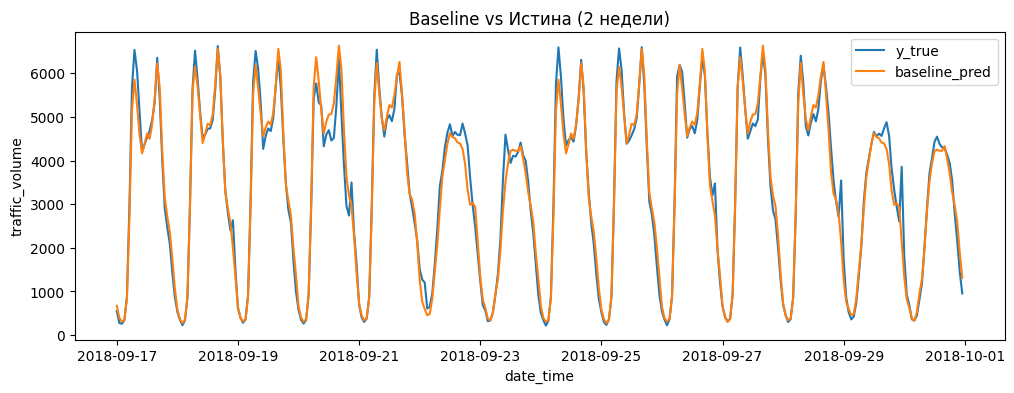

In [11]:

def baseline_predict(train_df, test_df):
    pivot = train_df.groupby(["weekday", "hour"])[y_col].mean()
    preds = []
    for ts, row in test_df.iterrows():
        preds.append(pivot.loc[row["weekday"], row["hour"]])
    return np.array(preds)

baseline_preds = baseline_predict(trainval_cut, test)
def metrics(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(1e-6, y_true))) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE%": mape}

base_scores = metrics(test[y_col].values, baseline_preds)
print("Baseline:", base_scores)

plt.figure(figsize=(12,4))
plt.plot(test.index, test[y_col].values, label="y_true")
plt.plot(test.index, baseline_preds, label="baseline_pred")
plt.title("Baseline vs Истина (2 недели)")
plt.xlabel("date_time"); plt.ylabel("traffic_volume")
plt.legend()
plt.show()


## 7) SARIMAX с недельной сезонностью (s=168) и temp как экзоген

Используем 5 признаков: ['temp', 'hour_sin', 'hour_cos', 'is_weekend', 'is_holiday']
Размер train: (1824, 6), test: (336, 6)
Параметры SARIMAX: order=(1, 0, 1), seasonal_order=(1, 0, 1, 168)
Начинаем обучение...
Обучение завершено!
                                      SARIMAX Results                                      
Dep. Variable:                      traffic_volume   No. Observations:                 1824
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 168)   Log Likelihood              -11553.907
Date:                             Tue, 04 Nov 2025   AIC                          23127.813
Time:                                     21:39:04   BIC                          23181.923
Sample:                                 07-03-2018   HQIC                         23147.872
                                      - 09-16-2018                                         
Covariance Type:                               opg                                         
                 coef    std err

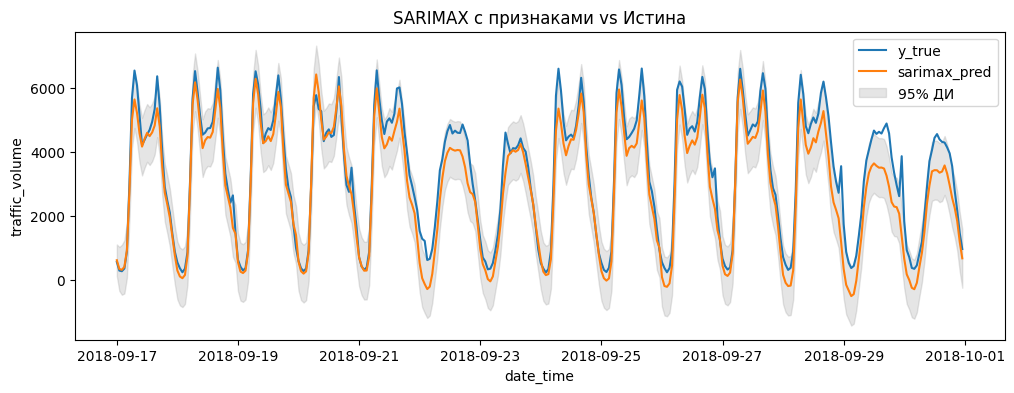

In [12]:
# Подготовим ряды для SARIMAX: используем y и отобранные признаки
feature_columns = [
    "temp",                    # температура
    "hour_sin", "hour_cos",    # циклические часы
    "is_weekend",              # выходные
    "is_holiday",              # праздники
]

# Выбираем только целевой столбец и признаки
sarimax_df = data[[y_col] + feature_columns].copy()
sarimax_df = sarimax_df.last("90D")
sarimax_train = sarimax_df.iloc[:-TEST_LEN]
sarimax_test = sarimax_df.iloc[-TEST_LEN:]

print(f"Используем {len(feature_columns)} признаков: {feature_columns}")
print(f"Размер train: {sarimax_train.shape}, test: {sarimax_test.shape}")

# Фиксированные параметры
order = (1, 0, 1)           # (p, d, q)
seasonal_order = (1, 0, 1, 168)  # (P, D, Q, s)

print(f"Параметры SARIMAX: order={order}, seasonal_order={seasonal_order}")
print("Начинаем обучение...")

# Обучим SARIMAX с множеством экзогенных переменных
sarimax = SARIMAX(
    sarimax_train[y_col],
    exog=sarimax_train[feature_columns],  # используем все признаки
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(
    disp=True,              # прогресс обучения
    maxiter=30,            # ограничиваем итерации
    method='lbfgs'         # метод оптимизации
)

print("Обучение завершено!")
print(sarimax.summary())

# Прогноз на тест с использованием признаков тестового набора
fcast = sarimax.get_forecast(
    steps=TEST_LEN,
    exog=sarimax_test[feature_columns]  # признаки для теста
)
sarimax_pred = fcast.predicted_mean.values
sarimax_ci = fcast.conf_int(alpha=0.05).values

sarimax_scores = metrics(sarimax_test[y_col].values, sarimax_pred)
print("SARIMAX с признаками:", sarimax_scores)

# Визуализация
plt.figure(figsize=(12,4))
plt.plot(sarimax_test.index, sarimax_test[y_col].values, label="y_true")
plt.plot(sarimax_test.index, sarimax_pred, label="sarimax_pred")
plt.fill_between(
    sarimax_test.index,
    sarimax_ci[:, 0], sarimax_ci[:, 1],
    alpha=0.2, color='gray', label="95% ДИ"
)
plt.title("SARIMAX с признаками vs Истина")
plt.xlabel("date_time"); plt.ylabel("traffic_volume")
plt.legend()
plt.show()

## 8) H2O AutoML (градиентные бустинги, стеккинг и т.п.)

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: [0.028s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate; [0.028s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate; openjdk version "25.0.1-internal" 2025-10-21; OpenJDK Runtime Environment (build 25.0.1-internal-adhoc.conda.src); OpenJDK 64-Bit Server VM (build 25.0.1-internal-adhoc.conda.src, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpfjfajgb8
  JVM stdout: /tmp/tmpfjfajgb8/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpfjfajgb8/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to 

H2O_cluster_uptime:,04 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.8
H2O_cluster_version_age:,27 days
H2O_cluster_name:,H2O_from_python_unknownUser_svptsd
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.152 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
model_id                                                    rmse      mse      mae      rmsle    mean_residual_deviance
StackedEnsemble_AllModels_4_AutoML_1_20251104_213920     218.649  47807.5  137.864  0.0992511                   47807.5
StackedEnsemble_AllModels_3_AutoML_1_20251104_213920     218.735  47844.9  137.873  0.0992678                   47844.9
StackedEnsemble_BestOfFamily_4_AutoML_1_20251104_213920  220.671  48695.8  139.254  0.101203                    48695.8
GBM_grid_1_AutoML_1_20251104_213920_model_14             222.805  49642.2  141.484  0.103551                    49642.2
GBM_grid_1_AutoML_1_20251104_213920_model_17             224.552  50423.5  141.91   0.0989814                   504

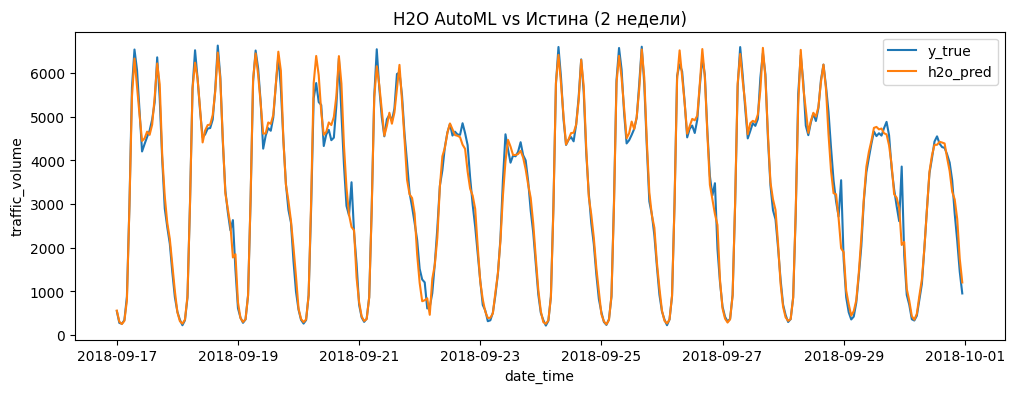

In [13]:

# Запуск кластера H2O
import h2o
from h2o.automl import H2OAutoML

h2o.init()

# Формируем обучающую/тестовую выборки для H2O
h2o_cols = feature_cols + [y_col]
h2o_train = h2o.H2OFrame(trainval_cut[h2o_cols])
h2o_test  = h2o.H2OFrame(test[h2o_cols])

x = feature_cols
y = y_col

# AutoML: ограничим временем, чтобы ноутбук был воспроизводимым.
aml = H2OAutoML(
    max_runtime_secs=600,  # ~10 минут
    stopping_metric="RMSE",
    sort_metric="RMSE",
    seed=123,
    exclude_algos=None  # оставим всё
)
aml.train(x=x, y=y, training_frame=h2o_train)

lb = aml.leaderboard
print(lb.head(rows=10))

leader = aml.leader
pred_h2o = leader.predict(h2o_test).as_data_frame().values.ravel()

h2o_scores = metrics(test[y_col].values, pred_h2o)
print("H2O AutoML:", h2o_scores)

# Приближённые доверительные интервалы для AutoML на основе остатков (гомоскедастичность — упрощение)
resid = test[y_col].values - pred_h2o
sigma = np.std(resid)
ci_low = pred_h2o - 1.96*sigma
ci_high = pred_h2o + 1.96*sigma

plt.figure(figsize=(12,4))
plt.plot(test.index, test[y_col].values, label="y_true")
plt.plot(test.index, pred_h2o, label="h2o_pred")
plt.title("H2O AutoML vs Истина (2 недели)")
plt.xlabel("date_time"); plt.ylabel("traffic_volume")
plt.legend()
plt.show()


## 9) Сравнение метрик на отложенных 2 неделях

                                     MAE        RMSE      MAPE%
model                                                          
Baseline weekday×hour         204.330643  300.311646   8.255341
SARIMAX (s=168) + exog(temp)  501.070221  623.869390  26.502124
H2O AutoML                    150.336873  241.725454   6.409912


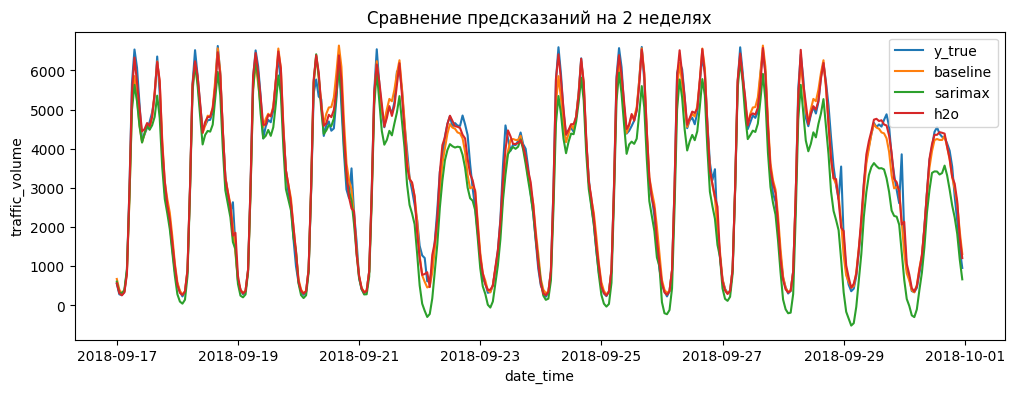

In [14]:

scores = pd.DataFrame([
    {"model":"Baseline weekday×hour", **base_scores},
    {"model":"SARIMAX (s=168) + exog(temp)", **sarimax_scores},
    {"model":"H2O AutoML", **h2o_scores},
]).set_index("model")

print(scores)

# Визуализация предсказаний всех моделей на одном графике (только сравнение уровней)
plt.figure(figsize=(12,4))
plt.plot(test.index, test[y_col].values, label="y_true")
plt.plot(test.index, baseline_preds, label="baseline")
plt.plot(test.index, sarimax_pred, label="sarimax")
plt.plot(test.index, pred_h2o, label="h2o")
plt.title("Сравнение предсказаний на 2 неделях")
plt.xlabel("date_time"); plt.ylabel("traffic_volume")
plt.legend()
plt.show()



### Выводы
- H2O AutoML построил стэккинг-ансамбль модель с использованием новых фич из tsfresh которая победила baseline по МАЕ, RMSE и MAP
- SARIMAX хуже бейзлайна - вероятно потому что обучался на слабых параметрах (не использовал все фичи). Мощности колаба не хватает для полноценного использования SARIMAX
